# African Credit Scoring — ML Project Lifecycle

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')
SEED = 42

---
## 1. Problem Framing

- **Goal:** Predict loan default (`Target = 1`) to reduce financial losses.
- **Type:** Binary classification. **Metric:** F1-Score (suited for imbalanced classes).
- **Input:** loan financial data. **Output:** default label `{0, 1}`.
- **Non-ML baseline:** always predict 0 → F1 = 0 on defaults, not useful.
- **Key challenges:** ~98% non-default vs ~2% default; unseen countries in test.

---
## 2. Data Collection

- Check size, missing values, and label distribution.
- Verify train/test representativeness — beware sampling bias (new countries in test).

> Place `Train.csv` and `Test.csv` in the same folder as this notebook.

In [2]:
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')

TARGET, ID = 'target', 'ID'

print('Train:', train.shape, '| Test:', test.shape)
print('\nMissing values:')
print(train.isnull().sum()[train.isnull().sum() > 0])
print(f'\nDefault rate: {train[TARGET].mean()*100:.2f}%')

# Sampling bias check
if 'country' in train.columns:
    unseen = set(test['country'].unique()) - set(train['country'].unique())
    print(f'Unseen countries in test: {unseen}')

train.head()

Train: (68654, 16) | Test: (18594, 15)

Missing values:
Series([], dtype: int64)

Default rate: 1.83%


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


---
## 3. Data Wrangling

- **Transformation:** parse dates → numeric. CatBoost handles categoricals natively — no label encoding needed for them.
- **Feature engineering:** repayment ratio, loan term in months.
- **Cleaning:** fill missing values with the median.
- Train + test are combined for consistent transformations. No leakage: no test labels used, no stats computed from test.

In [3]:
y        = train[TARGET].copy()
test_ids = test[ID].copy()
n_train  = len(train)

df = pd.concat([train.drop(columns=[TARGET, ID]), test.drop(columns=[ID])],
               axis=0).reset_index(drop=True)

# Parse dates → year, month, day
date_cols = []
for col in df.select_dtypes(include='object').columns:
    try:
        p = pd.to_datetime(df[col], errors='raise')
        df[col+'_year'], df[col+'_month'], df[col+'_day'] = p.dt.year, p.dt.month, p.dt.day
        date_cols.append(col)
    except Exception:
        pass
df.drop(columns=date_cols, inplace=True)

# Feature engineering
if 'total_amount' in df.columns and 'loan_amount' in df.columns:
    df['repayment_ratio'] = df['total_amount'] / (df['loan_amount'] + 1e-9)

if 'disbursement_date_month' in df.columns and 'due_date_month' in df.columns:
    df['loan_term_months'] = (df['due_date_year']  - df['disbursement_date_year'])  * 12 + \
                             (df['due_date_month'] - df['disbursement_date_month'])

# Identify categorical columns for CatBoost (pass as-is, no encoding needed)
cat_features = df.select_dtypes(include='object').columns.tolist()
for col in cat_features:
    df[col] = df[col].astype(str)  # CatBoost requires string or int for categoricals

# Fill missing
df[df.select_dtypes(include='number').columns] = \
    df.select_dtypes(include='number').fillna(df.select_dtypes(include='number').median())
df[cat_features] = df[cat_features].fillna('missing')

X_train, X_test = df.iloc[:n_train].copy(), df.iloc[n_train:].copy()
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Categorical features passed to CatBoost: {cat_features}')

X_train: (68654, 19) | X_test: (18594, 19)
Categorical features passed to CatBoost: ['country_id', 'loan_type', 'New_versus_Repeat']


---
## 4. Data Analysis

- Look at distributions and correlations with the target.
- Compare defaulters vs non-defaulters on key features.
- ⚠️ Correlation ≠ causation.

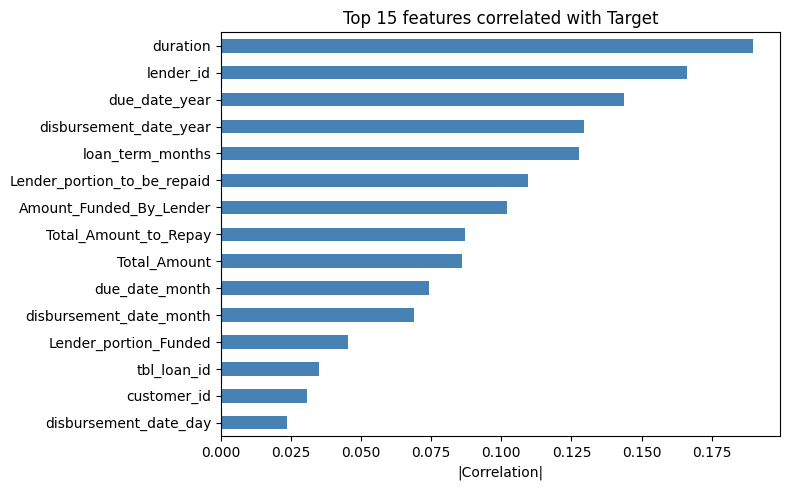

In [4]:
# Top numeric features correlated with target
corr = X_train.select_dtypes(include='number').corrwith(y).abs().sort_values(ascending=False)
corr.head(15).plot(kind='barh', color='steelblue', figsize=(8, 5),
                   title='Top 15 features correlated with Target')
plt.xlabel('|Correlation|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

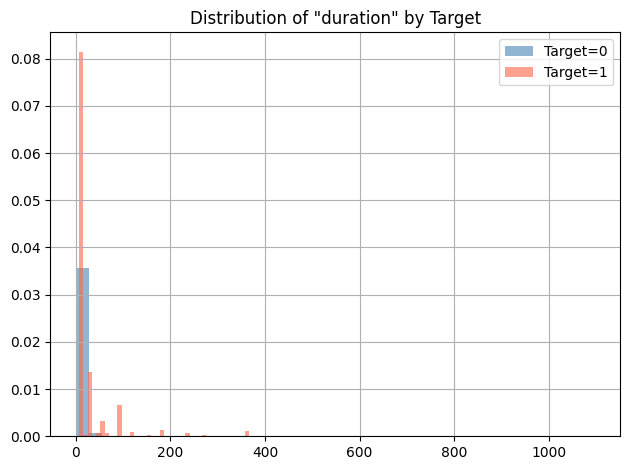

In [5]:
# Distribution of top feature by target
top = corr.index[0]
for label, color in zip([0, 1], ['steelblue', 'tomato']):
    X_train.loc[y == label, top].hist(bins=40, alpha=0.6, label=f'Target={label}',
                                       color=color, density=True)
plt.title(f'Distribution of "{top}" by Target')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Model Training & Evaluation

- **CatBoost**  it handles categorical features natively (no encoding needed), which is an advantage given we have country and loan type columns.
- Use **StratifiedKFold** (5 folds): train on training folds, evaluate on validation fold — never touch the test set.
- `scale_pos_weight` handles class imbalance.
- Tune the **decision threshold** on each validation fold to maximize F1 (default 0.5 is suboptimal here).
- Check **feature importance** to validate data quality and detect potential leakage.

In [6]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

# Get categorical feature indices for CatBoost
cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features if c in X_train.columns]

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    scale_pos_weight=scale_pos_weight,
    cat_features=cat_feature_indices,
    random_seed=SEED,
    verbose=0
)

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
f1_scores  = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    model.fit(X_train.iloc[tr_idx], y.iloc[tr_idx])
    val_proba = model.predict_proba(X_train.iloc[val_idx])[:, 1]
    oof_preds[val_idx] = val_proba
    test_preds += model.predict_proba(X_test)[:, 1] / 5

    thresholds = np.linspace(0.01, 0.99, 200)
    f1s = [f1_score(y.iloc[val_idx], (val_proba >= t).astype(int)) for t in thresholds]
    best_f1, best_t = max(f1s), thresholds[np.argmax(f1s)]
    f1_scores.append(best_f1)
    print(f'Fold {fold+1}/5 — F1: {best_f1:.4f}  (threshold: {best_t:.2f})')

print(f'\nMean CV F1: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}')

scale_pos_weight: 53.6
Fold 1/5 — F1: 0.7595  (threshold: 0.84)
Fold 2/5 — F1: 0.7932  (threshold: 0.76)
Fold 3/5 — F1: 0.7705  (threshold: 0.84)
Fold 4/5 — F1: 0.7822  (threshold: 0.87)
Fold 5/5 — F1: 0.7974  (threshold: 0.85)

Mean CV F1: 0.7806 ± 0.0141


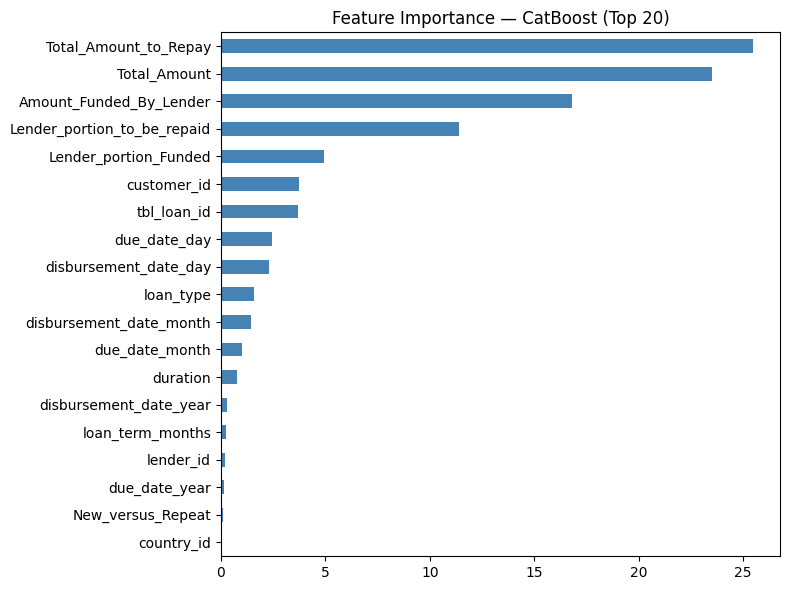

In [7]:
# Feature importance — validate that the model relies on meaningful features
pd.Series(model.get_feature_importance(), index=X_train.columns)\
  .sort_values(ascending=False).head(20)\
  .plot(kind='barh', color='steelblue', figsize=(8, 6),
        title='Feature Importance — CatBoost (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6. Model Deployment

- Apply the best threshold (from OOF predictions) to generate final labels on the test set.
- In production: version data & model, test each pipeline component, monitor for training-serving skew, retrain periodically on new data.

In [8]:
thresholds  = np.linspace(0.01, 0.99, 200)
f1s         = [f1_score(y, (oof_preds >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]
print(f'Best threshold: {best_thresh:.3f}  |  OOF F1: {max(f1s):.4f}')

submission = pd.DataFrame({'ID': test_ids,
                           'Target': (test_preds >= best_thresh).astype(int)})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved ')
submission.head()

Best threshold: 0.837  |  OOF F1: 0.7755
submission.csv saved 


,ID,Target
0,ID_269404226088267278,0
1,ID_255356300042267278,0
2,ID_257026243764267278,0
3,ID_264617299409267278,0
4,ID_247613296713267278,0
